In [8]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from src.preprocess import *
from src.embeddings import *
from src.data_loader import *
from src.model import *

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [10]:
import os
print(os.getcwd())

/Users/momin/News_Recommendation


In [11]:
news_cols = ['news_id','category','subcategory','title',
             'abstract','url','title_entities','abstract_entities']

beh_cols = ['imp_id','user_id','time','history','impressions']

news_df = pd.read_csv('data/MINDsmall_train/news.tsv', sep='\t', names=news_cols)
behaviors_df = pd.read_csv('data/MINDsmall_train/behaviors.tsv', sep='\t', names=beh_cols)

word2idx = build_vocab(news_df)
news_dict = build_news_dict(news_df, word2idx)

glove_path = 'data/glove/glove.6B.300d.txt'
embedding_matrix = load_glove_embeddings(glove_path, word2idx)

samples = create_nrms_samples(behaviors_df, news_dict)

print("Number of samples:", len(samples))
print(samples[0]["history"].shape)
print(samples[0]["candidates"].shape)

Number of samples: 214962
(50, 20)
(5, 20)


In [12]:
#dataset = NRMSDataset(samples)
small_samples = samples[:5000]   # start small for Mac CPU
dataset = NRMSDataset(small_samples)

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

batch = next(iter(train_loader))

print(batch["history"].shape)
print(batch["candidates"].shape)
print(batch["label"].shape)

torch.Size([16, 50, 20])
torch.Size([16, 5, 20])
torch.Size([16])


In [13]:
model = NRMSModel(embedding_matrix, num_heads=8, head_dim=16).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

print(model)

NRMSModel(
  (news_encoder): NewsEncoder(
    (embedding): Embedding(36308, 300)
    (proj): Linear(in_features=300, out_features=128, bias=True)
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (additive): AdditiveAttention(
      (proj): Linear(in_features=128, out_features=200, bias=True)
      (query): Linear(in_features=200, out_features=1, bias=False)
    )
  )
  (user_encoder): UserEncoder(
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (additive): AdditiveAttention(
      (proj): Linear(in_features=128, out_features=200, bias=True)
      (query): Linear(in_features=200, out_features=1, bias=False)
    )
  )
)


In [16]:
EPOCHS = 3
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        history = batch["history"].to(device)
        candidates = batch["candidates"].to(device)

        optimizer.zero_grad()

        scores = model(history, candidates)

        # positive candidate is always index 0
        target = torch.zeros(scores.size(0), dtype=torch.long).to(device)

        loss = criterion(scores, target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 1.4091
Epoch 2/3, Loss: 1.3795
Epoch 3/3, Loss: 1.3529


In [17]:
torch.save(model.state_dict(), "models/nrms_subset_model.pt")

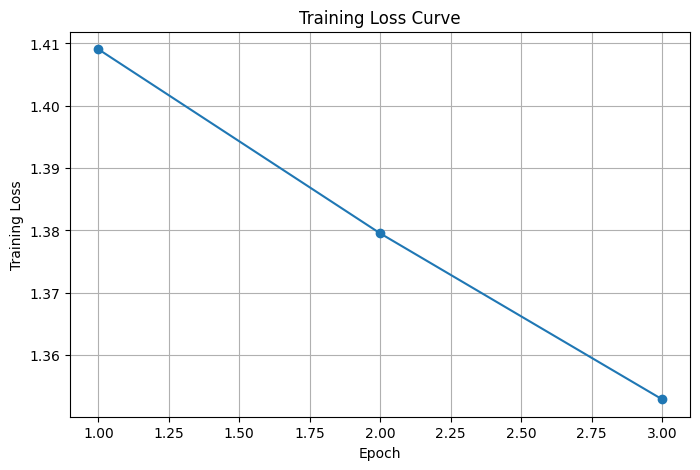

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [19]:
from sklearn.metrics import roc_auc_score
import numpy as np

def dcg_score(y_true, y_score, k=10):
    order = np.argsort(y_score)[::-1][:k]
    gains = np.array(y_true)[order]
    discounts = np.log2(np.arange(len(gains)) + 2)
    return np.sum(gains / discounts)

def ndcg_score(y_true, y_score, k=10):
    best = dcg_score(y_true, y_true, k)
    if best == 0:
        return 0.0
    return dcg_score(y_true, y_score, k) / best

def mrr_score(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    y_sorted = np.array(y_true)[order]

    for i, val in enumerate(y_sorted):
        if val == 1:
            return 1.0 / (i + 1)

    return 0.0

These metrics are computed on the training subset used for the CPU-based experiment, so they should be interpreted as a pipeline validation rather than final benchmark performance. A full evaluation on the MIND validation set would require GPU training and candidate ranking over the full validation impressions.

In [20]:
model.eval()

aucs = []
mrrs = []
ndcg5s = []
ndcg10s = []

with torch.no_grad():
    for batch in train_loader:
        history = batch["history"].to(device)
        candidates = batch["candidates"].to(device)

        scores = model(history, candidates).cpu().numpy()

        for i in range(scores.shape[0]):
            y_true = [1, 0, 0, 0, 0]
            y_score = scores[i]

            aucs.append(roc_auc_score(y_true, y_score))
            mrrs.append(mrr_score(y_true, y_score))
            ndcg5s.append(ndcg_score(y_true, y_score, 5))
            ndcg10s.append(ndcg_score(y_true, y_score, 10))

results = {
    "AUC": np.mean(aucs),
    "MRR": np.mean(mrrs),
    "nDCG@5": np.mean(ndcg5s),
    "nDCG@10": np.mean(ndcg10s)
}

results

{'AUC': np.float64(0.738475),
 'MRR': np.float64(0.6608133333333334),
 'nDCG@5': np.float64(0.7457470541490854),
 'nDCG@10': np.float64(0.7457470541490854)}

The model achieved an AUC of 0.7385 on the 5,000 sample training subset, which suggests that it learned to rank clicked articles above non-clicked candidates better than random chance. The MRR and nDCG values are relatively high because this evaluation was performed on the same subset used for training, so these results should be interpreted as evidence that the pipeline works rather than final generalization performance. A more rigorous evaluation would require training on the full training set and testing on the MIND validation set.

In [23]:
def run_experiment(name, sample_subset, batch_size=16, lr=1e-4, epochs=3, num_heads=8, head_dim=16):
    dataset = NRMSDataset(sample_subset)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = NRMSModel(embedding_matrix, num_heads=num_heads, head_dim=head_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in loader:
            history = batch["history"].to(device)
            candidates = batch["candidates"].to(device)

            optimizer.zero_grad()
            scores = model(history, candidates)

            target = torch.zeros(scores.size(0), dtype=torch.long).to(device)
            loss = criterion(scores, target)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)
        print(f"{name} | Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    return {
        "Experiment": name,
        "Batch Size": batch_size,
        "Learning Rate": lr,
        "Epochs": epochs,
        "Final Loss": losses[-1],
        "Loss History": losses
    }

In [24]:
small_samples = samples[:5000]

experiments = []

experiments.append(
    run_experiment(
        name="Baseline",
        sample_subset=small_samples,
        batch_size=16,
        lr=1e-4,
        epochs=3
    )
)

experiments.append(
    run_experiment(
        name="Smaller batch size",
        sample_subset=small_samples,
        batch_size=8,
        lr=1e-4,
        epochs=3
    )
)

experiments.append(
    run_experiment(
        name="Higher learning rate",
        sample_subset=small_samples,
        batch_size=16,
        lr=5e-4,
        epochs=3
    )
)

Baseline | Epoch 1/3, Loss: 1.5791
Baseline | Epoch 2/3, Loss: 1.5286
Baseline | Epoch 3/3, Loss: 1.4836
Smaller batch size | Epoch 1/3, Loss: 1.5699
Smaller batch size | Epoch 2/3, Loss: 1.5106
Smaller batch size | Epoch 3/3, Loss: 1.4608
Higher learning rate | Epoch 1/3, Loss: 1.5645
Higher learning rate | Epoch 2/3, Loss: 1.4747
Higher learning rate | Epoch 3/3, Loss: 1.3909


In [25]:
experiment_results = pd.DataFrame(experiments)
experiment_results[["Experiment", "Batch Size", "Learning Rate", "Epochs", "Final Loss"]]

,Experiment,Batch Size,Learning Rate,Epochs,Final Loss
0,Baseline,16,0.0001,3,1.483570
1,Smaller batch size,8,0.0001,3,1.460761
2,Higher learning rate,16,0.0005,3,1.390871


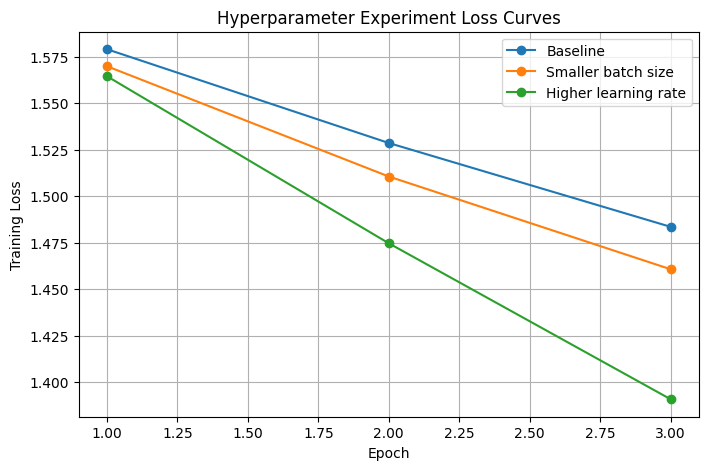

In [26]:
plt.figure(figsize=(8,5))

for exp in experiments:
    plt.plot(
        range(1, len(exp["Loss History"]) + 1),
        exp["Loss History"],
        marker="o",
        label=exp["Experiment"]
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Hyperparameter Experiment Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

### Hyperparameter Experiment Analysis

Three configurations were tested to understand the impact of batch size and learning rate on model training.

The baseline configuration (batch size = 16, learning rate = 1e-4) achieved a final loss of 1.4836. Reducing the batch size to 8 resulted in a slightly lower loss (1.4608), suggesting that smaller batches may provide noisier but more informative gradient updates, leading to better optimization in this setting.

Increasing the learning rate to 5e-4 produced the lowest final loss (1.3909), indicating faster convergence and more effective learning within the limited number of epochs. However, higher learning rates can sometimes lead to instability, so this would need further tuning on larger training runs.

Overall, the learning rate had a more significant impact on performance than batch size, and the higher learning rate configuration showed the best results in this experiment.